In [ ]:
import pandas as pd
from pathlib import Path

base_dir = Path.cwd()
if base_dir.name == "Notebook":
    base_dir = base_dir.parent

data_path = base_dir / "data" / "WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(data_path)
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
def cap_outliers_iqr(series):
    """
    Caps outliers in a pandas Series using the IQR method.
    Values below Q1 - 1.5*IQR are capped at Q1 - 1.5*IQR.
    Values above Q3 + 1.5*IQR are capped at Q3 + 1.5*IQR.

    Args:
        series (pd.Series): The input Series.

    Returns:
        pd.Series: The Series with outliers capped.
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    # Cap outliers
    return series.clip(lower=lower_fence, upper=upper_fence)

# Identify continuous numerical columns for outlier treatment
# Exclude columns that are ordinal or identifiers as IQR capping might not be appropriate
continuous_numerical_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Display descriptive statistics before capping
print("Descriptive Statistics BEFORE Outlier Capping:")
display(df[continuous_numerical_cols].describe())

# Apply outlier capping to the selected columns
for col in continuous_numerical_cols:
    df.loc[:, col] = cap_outliers_iqr(df[col])

# Display descriptive statistics after capping
print("\nDescriptive Statistics AFTER Outlier Capping:")
display(df[continuous_numerical_cols].describe())

Descriptive Statistics BEFORE Outlier Capping:


,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,65.891156,6502.931293,14313.103401,2.693197,15.209524,11.279592,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,20.329428,4707.956783,7117.786044,2.498009,3.659938,7.780782,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,30.000000,1009.000000,2094.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,48.000000,2911.000000,8047.000000,1.000000,12.000000,6.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,66.000000,4919.000000,14235.500000,2.000000,14.000000,10.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,83.750000,8379.000000,20461.500000,4.000000,18.000000,15.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,100.000000,19999.000000,26999.000000,9.000000,25.000000,40.000000,40.000000,18.000000,15.000000,17.000000



Descriptive Statistics AFTER Outlier Capping:


C:\Users\arind\AppData\Local\Temp\ipykernel_10100\3607169243.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[8. 1. 6. ... 1. 2. 2.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, col] = cap_outliers_iqr(df[col])
C:\Users\arind\AppData\Local\Temp\ipykernel_10100\3607169243.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 8. 10.  7. ...  6. 17.  6.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, col] = cap_outliers_iqr(df[col])
C:\Users\arind\AppData\Local\Temp\ipykernel_10100\3607169243.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4. 7. 0. ... 2. 6. 3.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,65.891156,6361.891837,14313.103401,2.675510,15.209524,11.103061,6.617687,4.207823,1.922789,4.107483
std,9.135373,403.509100,8.106864,20.329428,4353.345470,7117.786044,2.454656,3.659938,7.303828,4.989788,3.555335,2.478222,3.517487
min,18.000000,102.000000,1.000000,30.000000,1009.000000,2094.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,48.000000,2911.000000,8047.000000,1.000000,12.000000,6.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,66.000000,4919.000000,14235.500000,2.000000,14.000000,10.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,83.750000,8379.000000,20461.500000,4.000000,18.000000,15.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,100.000000,16581.000000,26999.000000,8.500000,25.000000,28.500000,18.000000,14.500000,7.500000,14.500000


In [12]:
import pandas as pd

def load_and_initial_preprocess(file_path):
    """
    Loads the HR Attrition dataset, performs initial preprocessing steps including
    outlier capping, converting 'Attrition' to numerical, and dropping uninformative columns.

    Args:
        file_path (str): The path to the HR Employee Attrition CSV file.

    Returns:
        tuple: A tuple containing:
            - df_processed (pd.DataFrame): The DataFrame after initial preprocessing.
            - X_raw (pd.DataFrame): Features for further engineering.
            - y (pd.Series): The target variable 'Attrition_numeric'.
    """
    df = pd.read_csv(file_path)

    # Convert 'Attrition' to numerical (Yes=1, No=0)
    df['Attrition_numeric'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

    # Identify continuous numerical columns for outlier treatment
    continuous_numerical_cols = [
        'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
        'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
        'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
    ]

    # Apply outlier capping to the selected columns
    for col in continuous_numerical_cols:
        # Assuming cap_outliers_iqr is defined globally or imported
        df[col] = cap_outliers_iqr(df[col])

    # Columns identified as uninformative or redundant for model training
    exclude_cols_for_training = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18', 'Attrition']
    df_processed = df.drop(columns=exclude_cols_for_training, errors='ignore')

    # Separate features (X_raw) and target (y)
    X_raw = df_processed.drop(columns=['Attrition_numeric'])
    y = df_processed['Attrition_numeric']

    return df_processed, X_raw, y

In [52]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def apply_feature_engineering_and_scaling(X_raw):
    """
    Applies feature engineering (one-hot encoding) and scaling (StandardScaler)
    to the raw features.

    Args:
        X_raw (pd.DataFrame): The raw features DataFrame.

    Returns:
        tuple: A tuple containing:
            - X (pd.DataFrame): The processed features DataFrame.
            - scaler: The fitted StandardScaler.
            - categorical_cols_X (list): List of categorical column names in X after encoding.
            - numerical_cols_X (list): List of numerical column names in X.
    """
    # Identify categorical and numerical columns
    categorical_cols = X_raw.select_dtypes(include='object').columns.tolist()
    numerical_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Apply One-Hot Encoding to categorical features
    X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True, dtype=int)

    # Get the names of the newly created categorical columns
    new_categorical_cols = [col for col in X_encoded.columns if col not in numerical_cols]

    # Initialize StandardScaler
    scaler = StandardScaler()

    # Scale numerical features
    X_scaled_numerical = scaler.fit_transform(X_encoded[numerical_cols])

    # Convert scaled numerical features back to DataFrame
    X_scaled_numerical_df = pd.DataFrame(X_scaled_numerical, columns=numerical_cols, index=X_encoded.index)

    # Combine scaled numerical features with one-hot encoded categorical features
    X = pd.concat([X_scaled_numerical_df, X_encoded[new_categorical_cols]], axis=1)

    return X, scaler, new_categorical_cols, numerical_cols

With the utility functions defined above, we can now refactor the initial data loading and preparation steps. First, we'll load the data and perform initial preprocessing to get `X_raw` and `y`. Then, we'll apply feature engineering (one-hot encoding and scaling) to transform `X_raw` into `X_processed`.

## Exploratory Data Analysis (EDA)

Let's get an overview of the DataFrame, including its structure (data types, non-null counts) and descriptive statistics for numerical columns.

In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [14]:
display(df.describe())

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.103061,2.799320,2.761224,6.617687,4.207823,1.922789,4.107483
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.303828,1.289271,0.706476,4.989788,3.555335,2.478222,3.517487
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,28.500000,6.000000,4.000000,18.000000,14.500000,7.500000,14.500000


Now, let's check for any missing values in the dataset.

In [55]:
display(df.isnull().sum())

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


### Distribution of Numerical Features

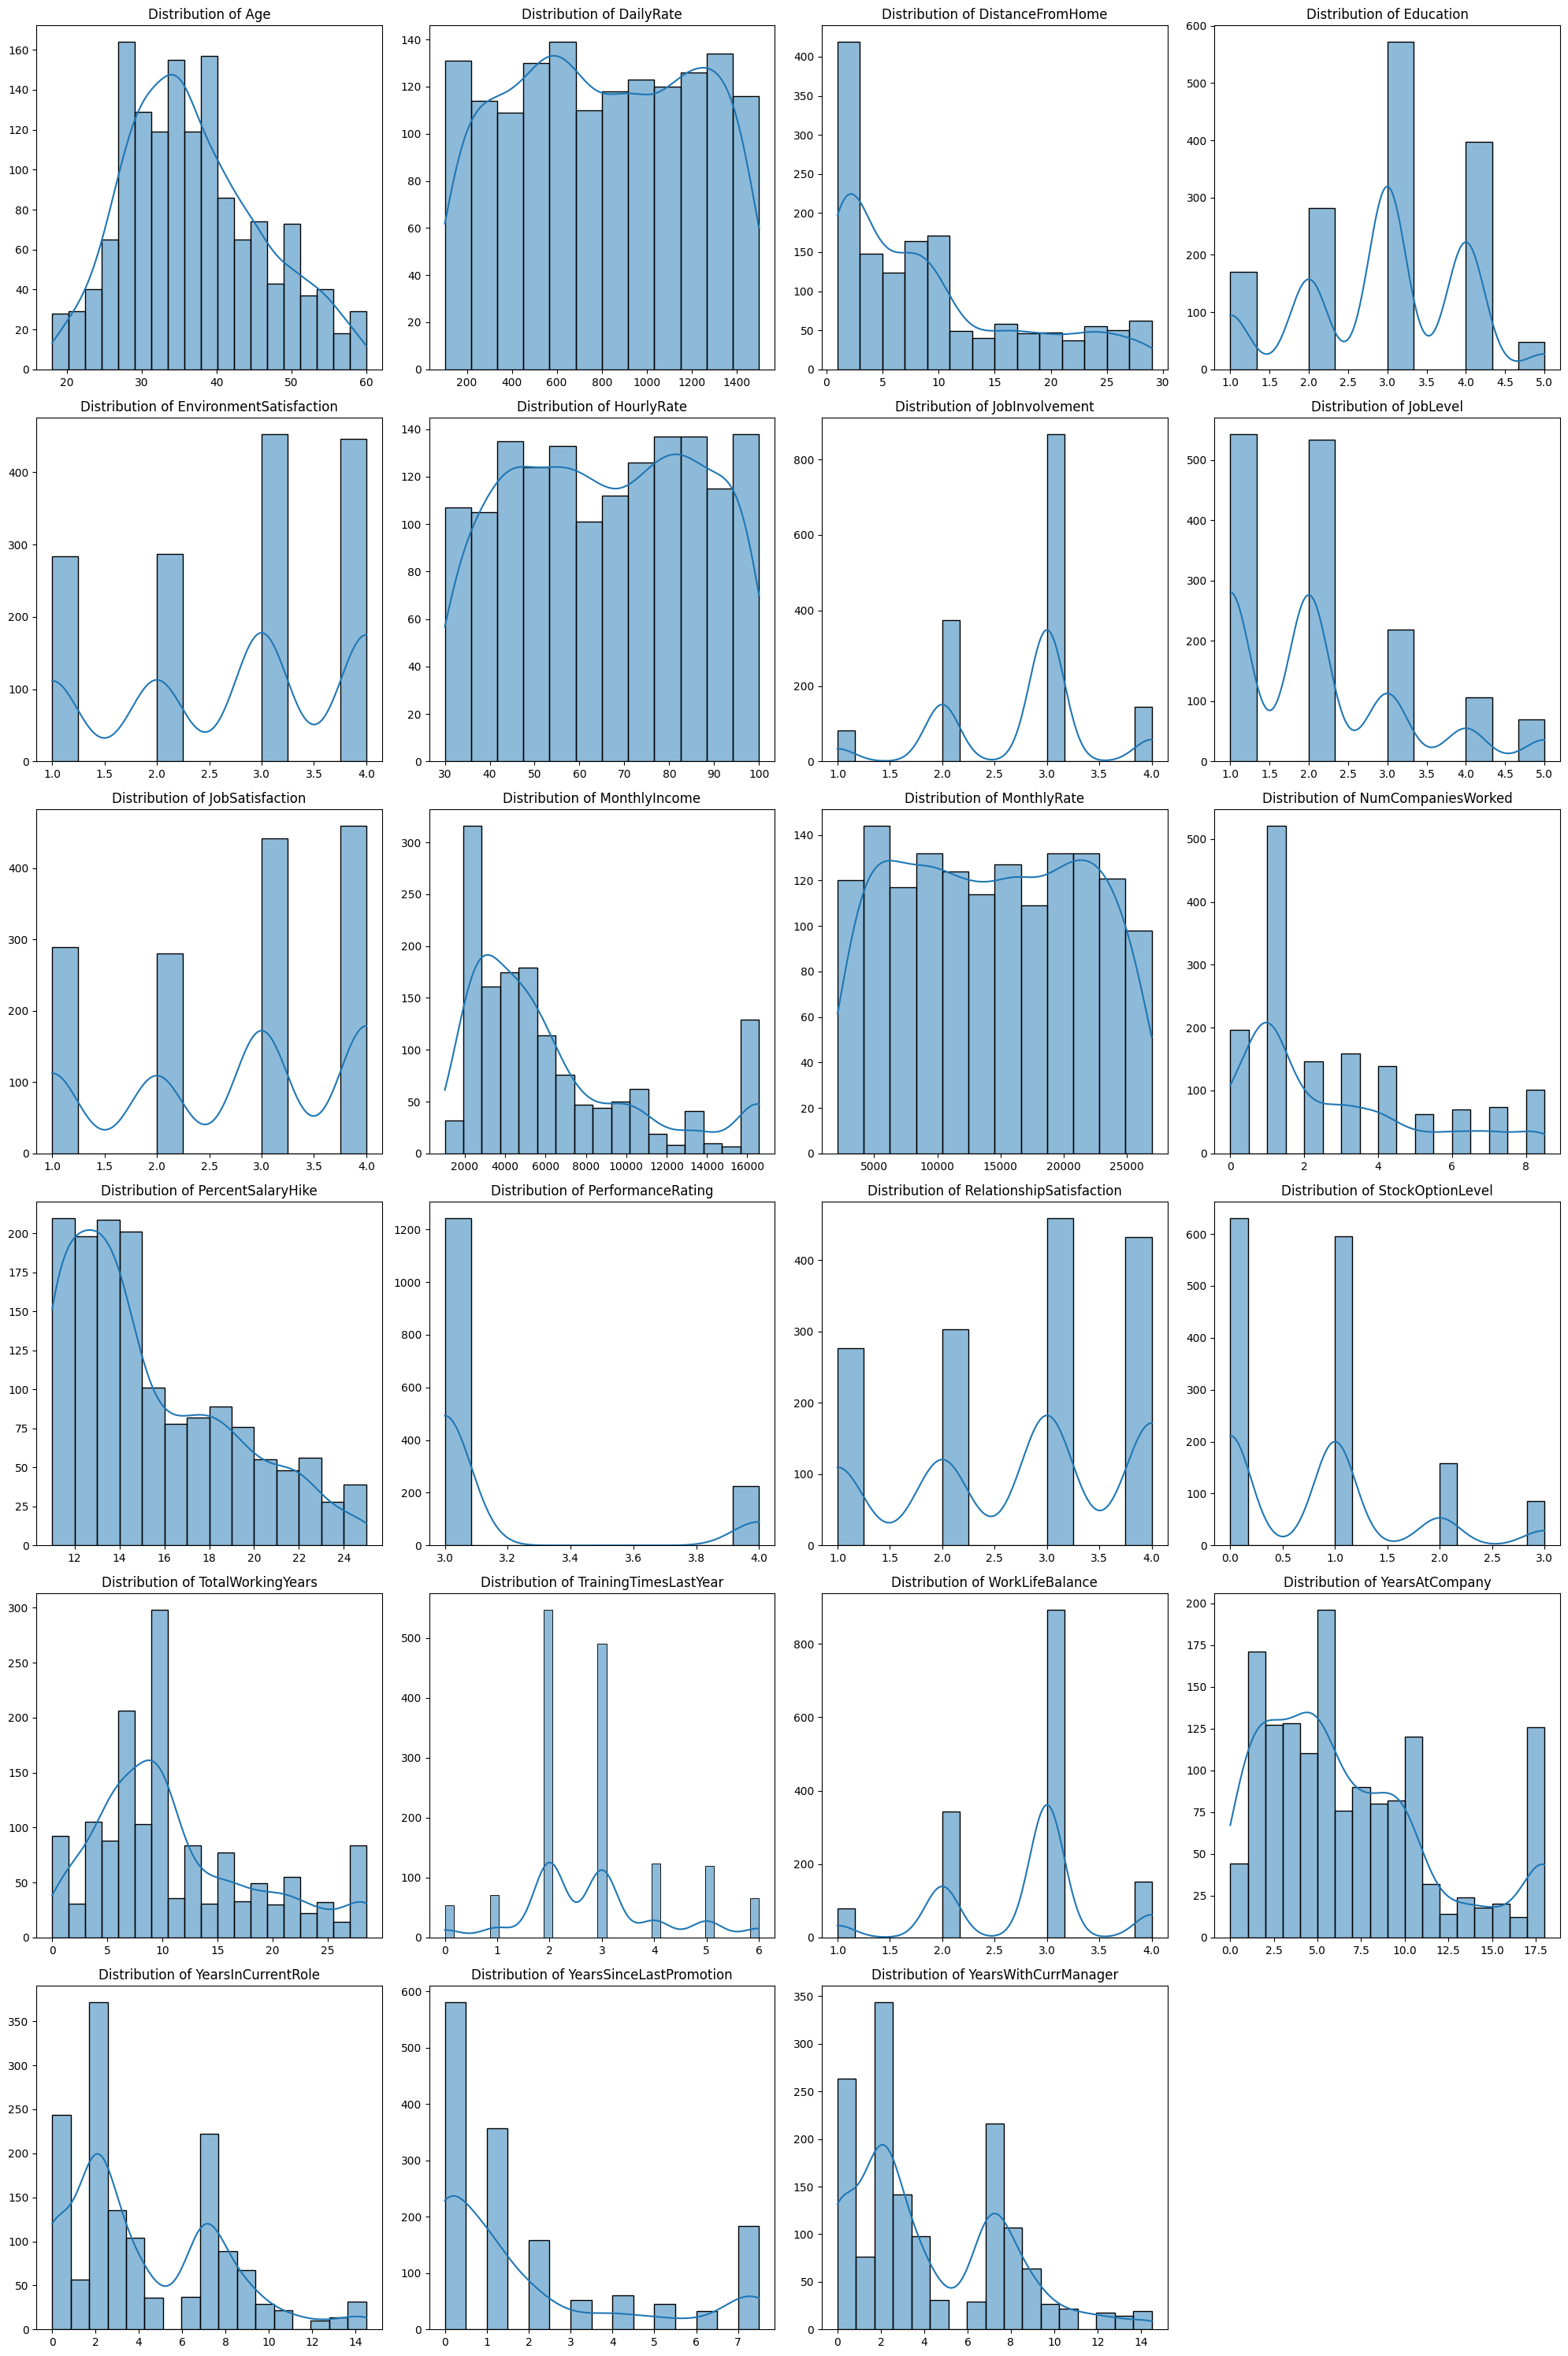

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for plotting, excluding 'EmployeeCount' and 'StandardHours'
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_cols = ['EmployeeCount', 'StandardHours', 'EmployeeNumber'] # EmployeeNumber is an ID, not a feature
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=len(numerical_cols)//4 + 1, ncols=4, figsize=(20, 5 * (len(numerical_cols)//4 + 1)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Distribution of Categorical Features

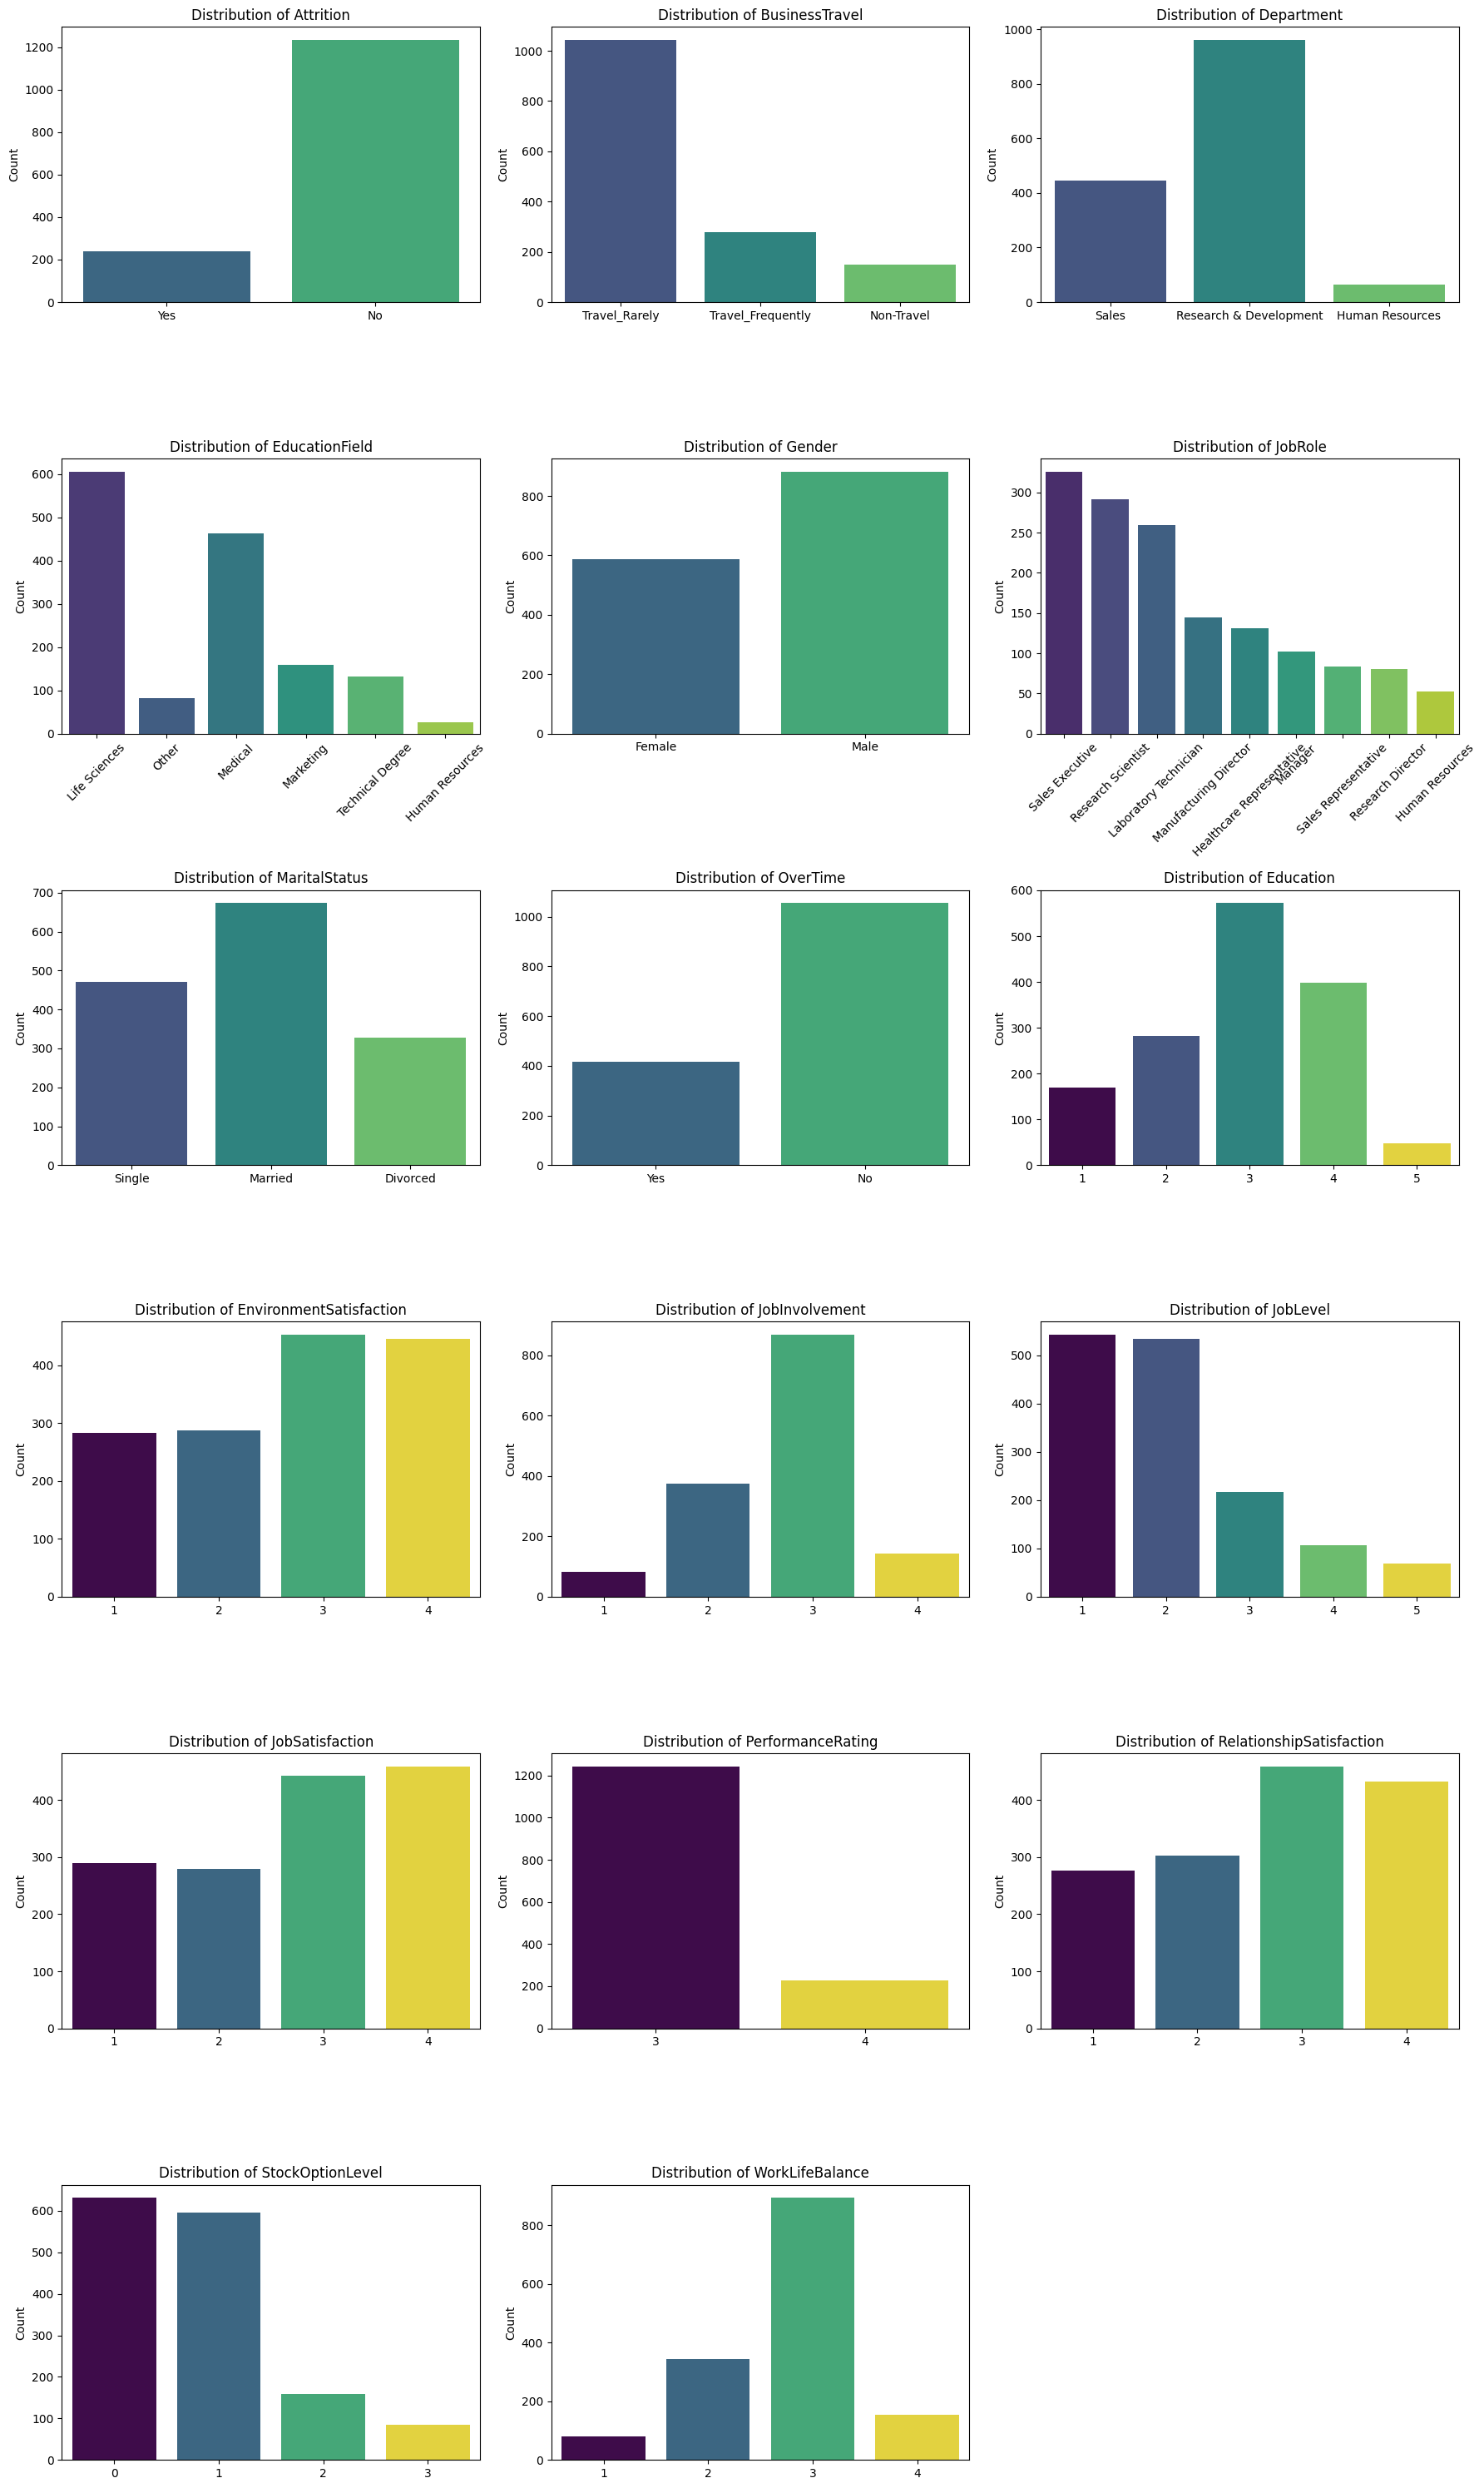

In [57]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Also consider numerical columns that are likely categorical (e.g., ratings, levels)
ordinal_cols = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
    'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'WorkLifeBalance'
]

categorical_cols.extend(ordinal_cols)

# Exclude columns that were identified as constants or identifiers
exclude_cols = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18'] # Over18 is likely constant based on common datasets of this type
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

# Set up the matplotlib figure and axes
num_plots = len(categorical_cols)
num_rows = (num_plots // 3) + (1 if num_plots % 3 > 0 else 0)

fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(18, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    # Rotate x-axis labels if there are too many categories
    if df[col].nunique() > 5:
        axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Correlation Analysis

Let's examine the correlation matrix for numerical features to understand their relationships. We will visualize this using a heatmap.

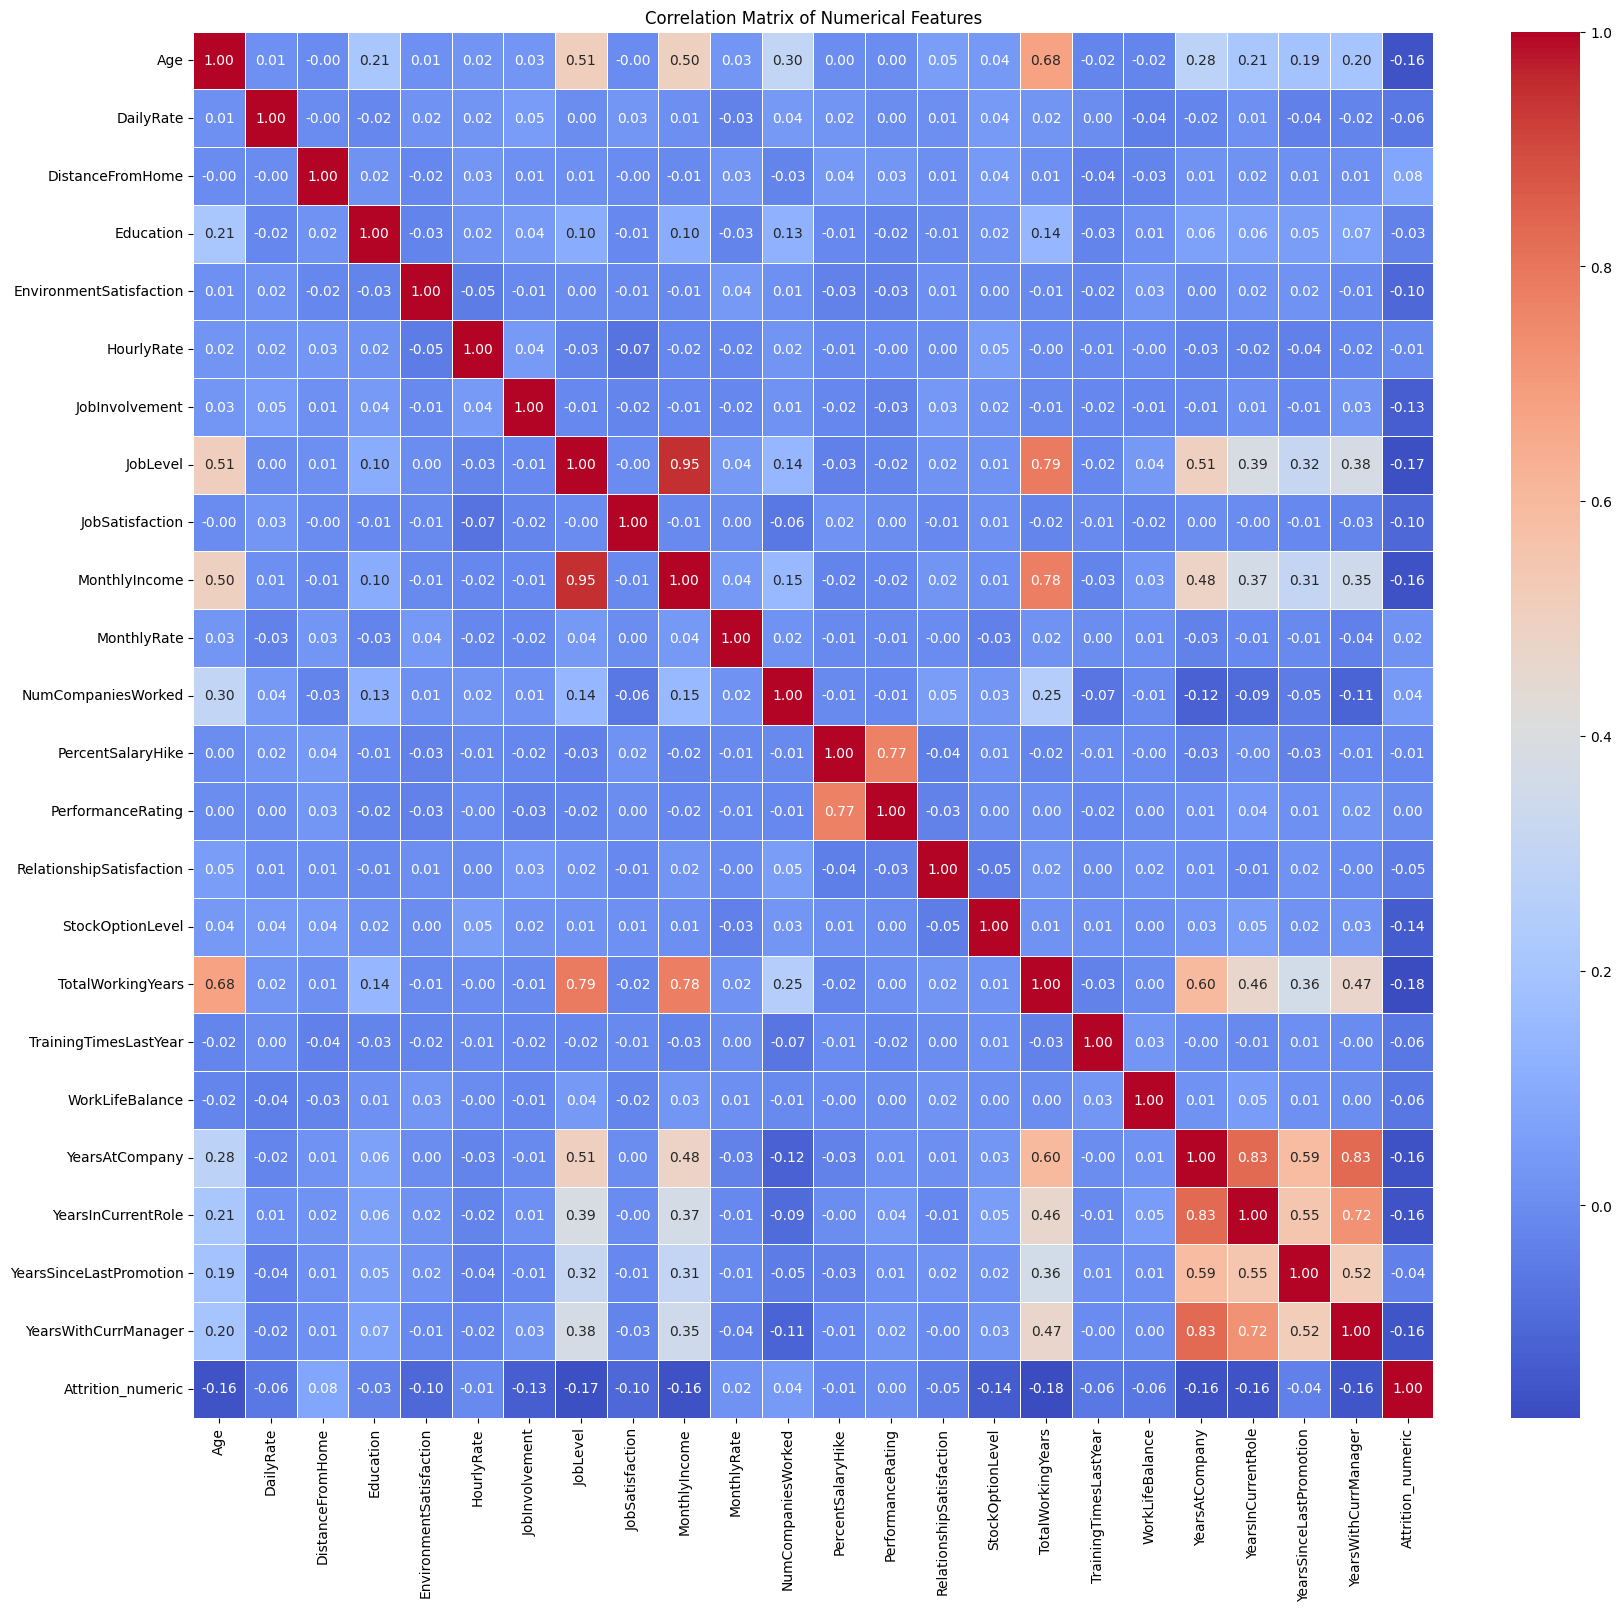

In [58]:
# Convert 'Attrition' to numerical (Yes=1, No=0) for correlation analysis
df['Attrition_numeric'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Select numerical columns for correlation, including the new 'Attrition_numeric'
# Re-using the previously defined numerical_cols and adding 'Attrition_numeric'
correlation_cols = [col for col in numerical_cols if col != 'Attrition'] # Ensure 'Attrition' object type is not in numerical_cols
correlation_cols.append('Attrition_numeric')

# Calculate the correlation matrix
corr_matrix = df[correlation_cols].corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Bivariate Analysis with Attrition

Now, let's specifically look at how each feature relates to the target variable 'Attrition'.

#### Numerical Features vs. Attrition

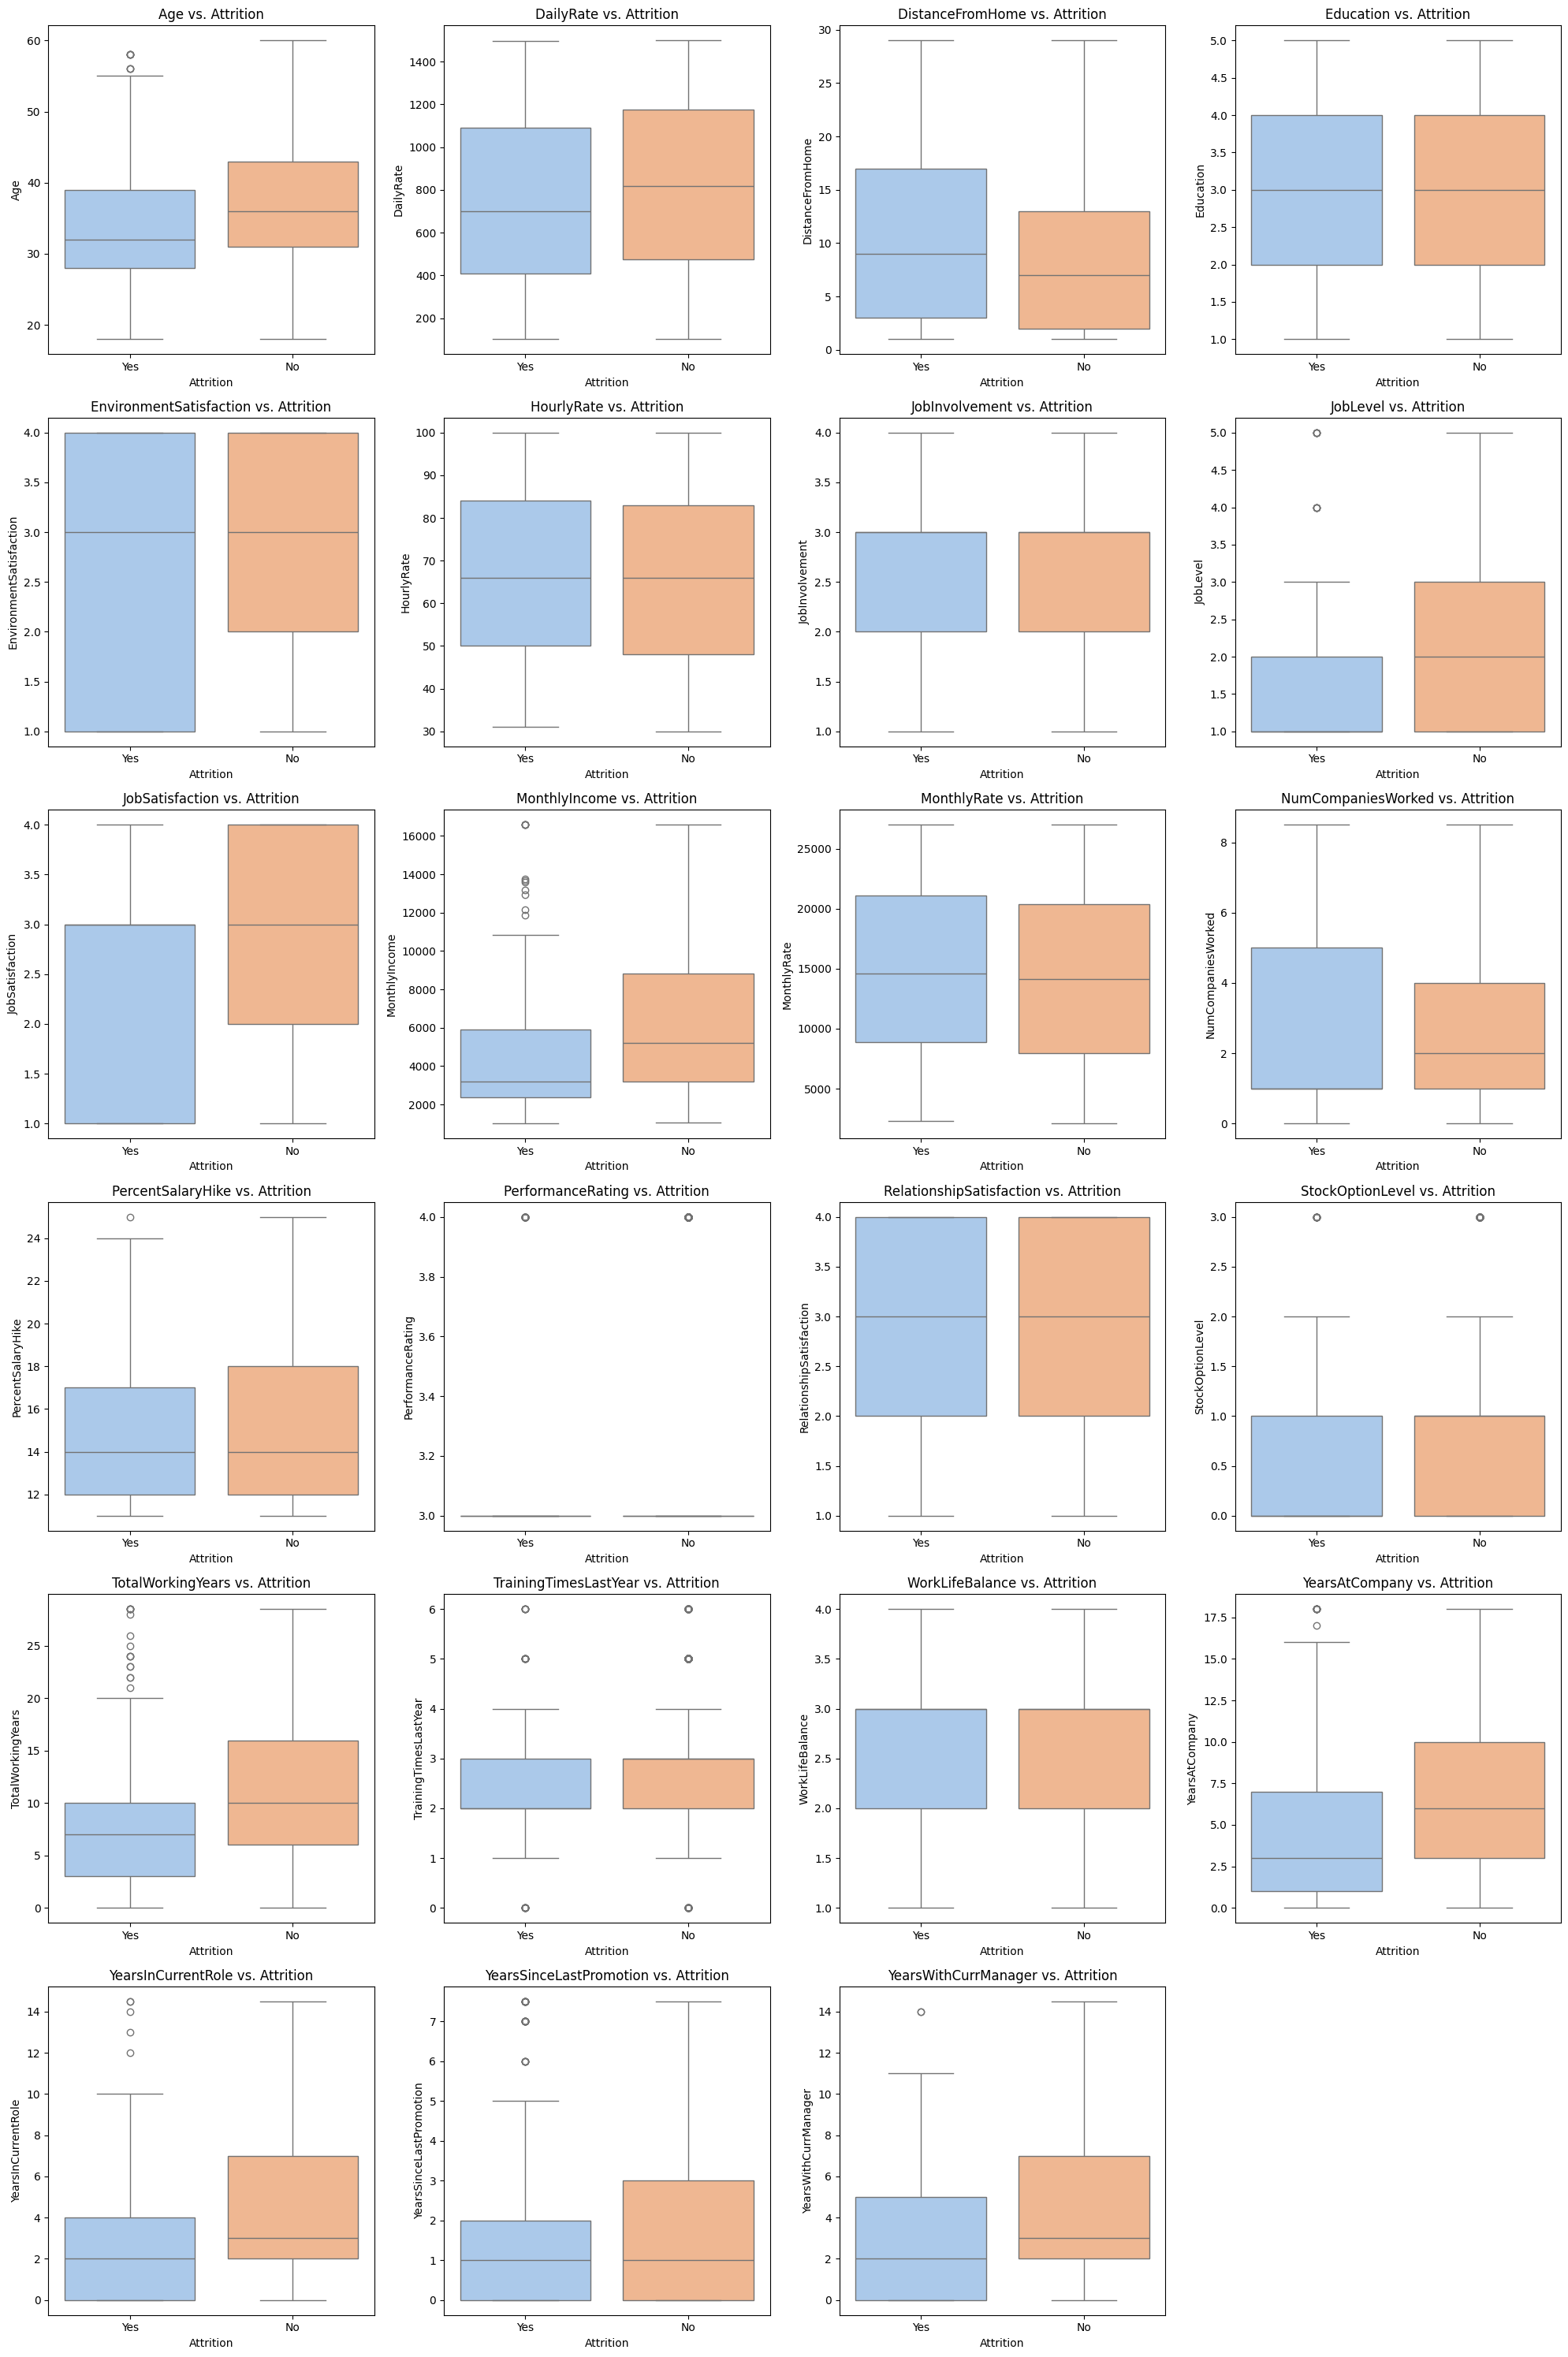

In [59]:
fig, axes = plt.subplots(nrows=len(numerical_cols)//4 + 1, ncols=4, figsize=(20, 5 * (len(numerical_cols)//4 + 1)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if col != 'Attrition_numeric': # Avoid plotting Attrition against itself
        sns.boxplot(x='Attrition', y=col, data=df, ax=axes[i], palette='pastel', hue='Attrition', legend=False)
        axes[i].set_title(f'{col} vs. Attrition')
        axes[i].set_xlabel('Attrition')
        axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Categorical Features vs. Attrition

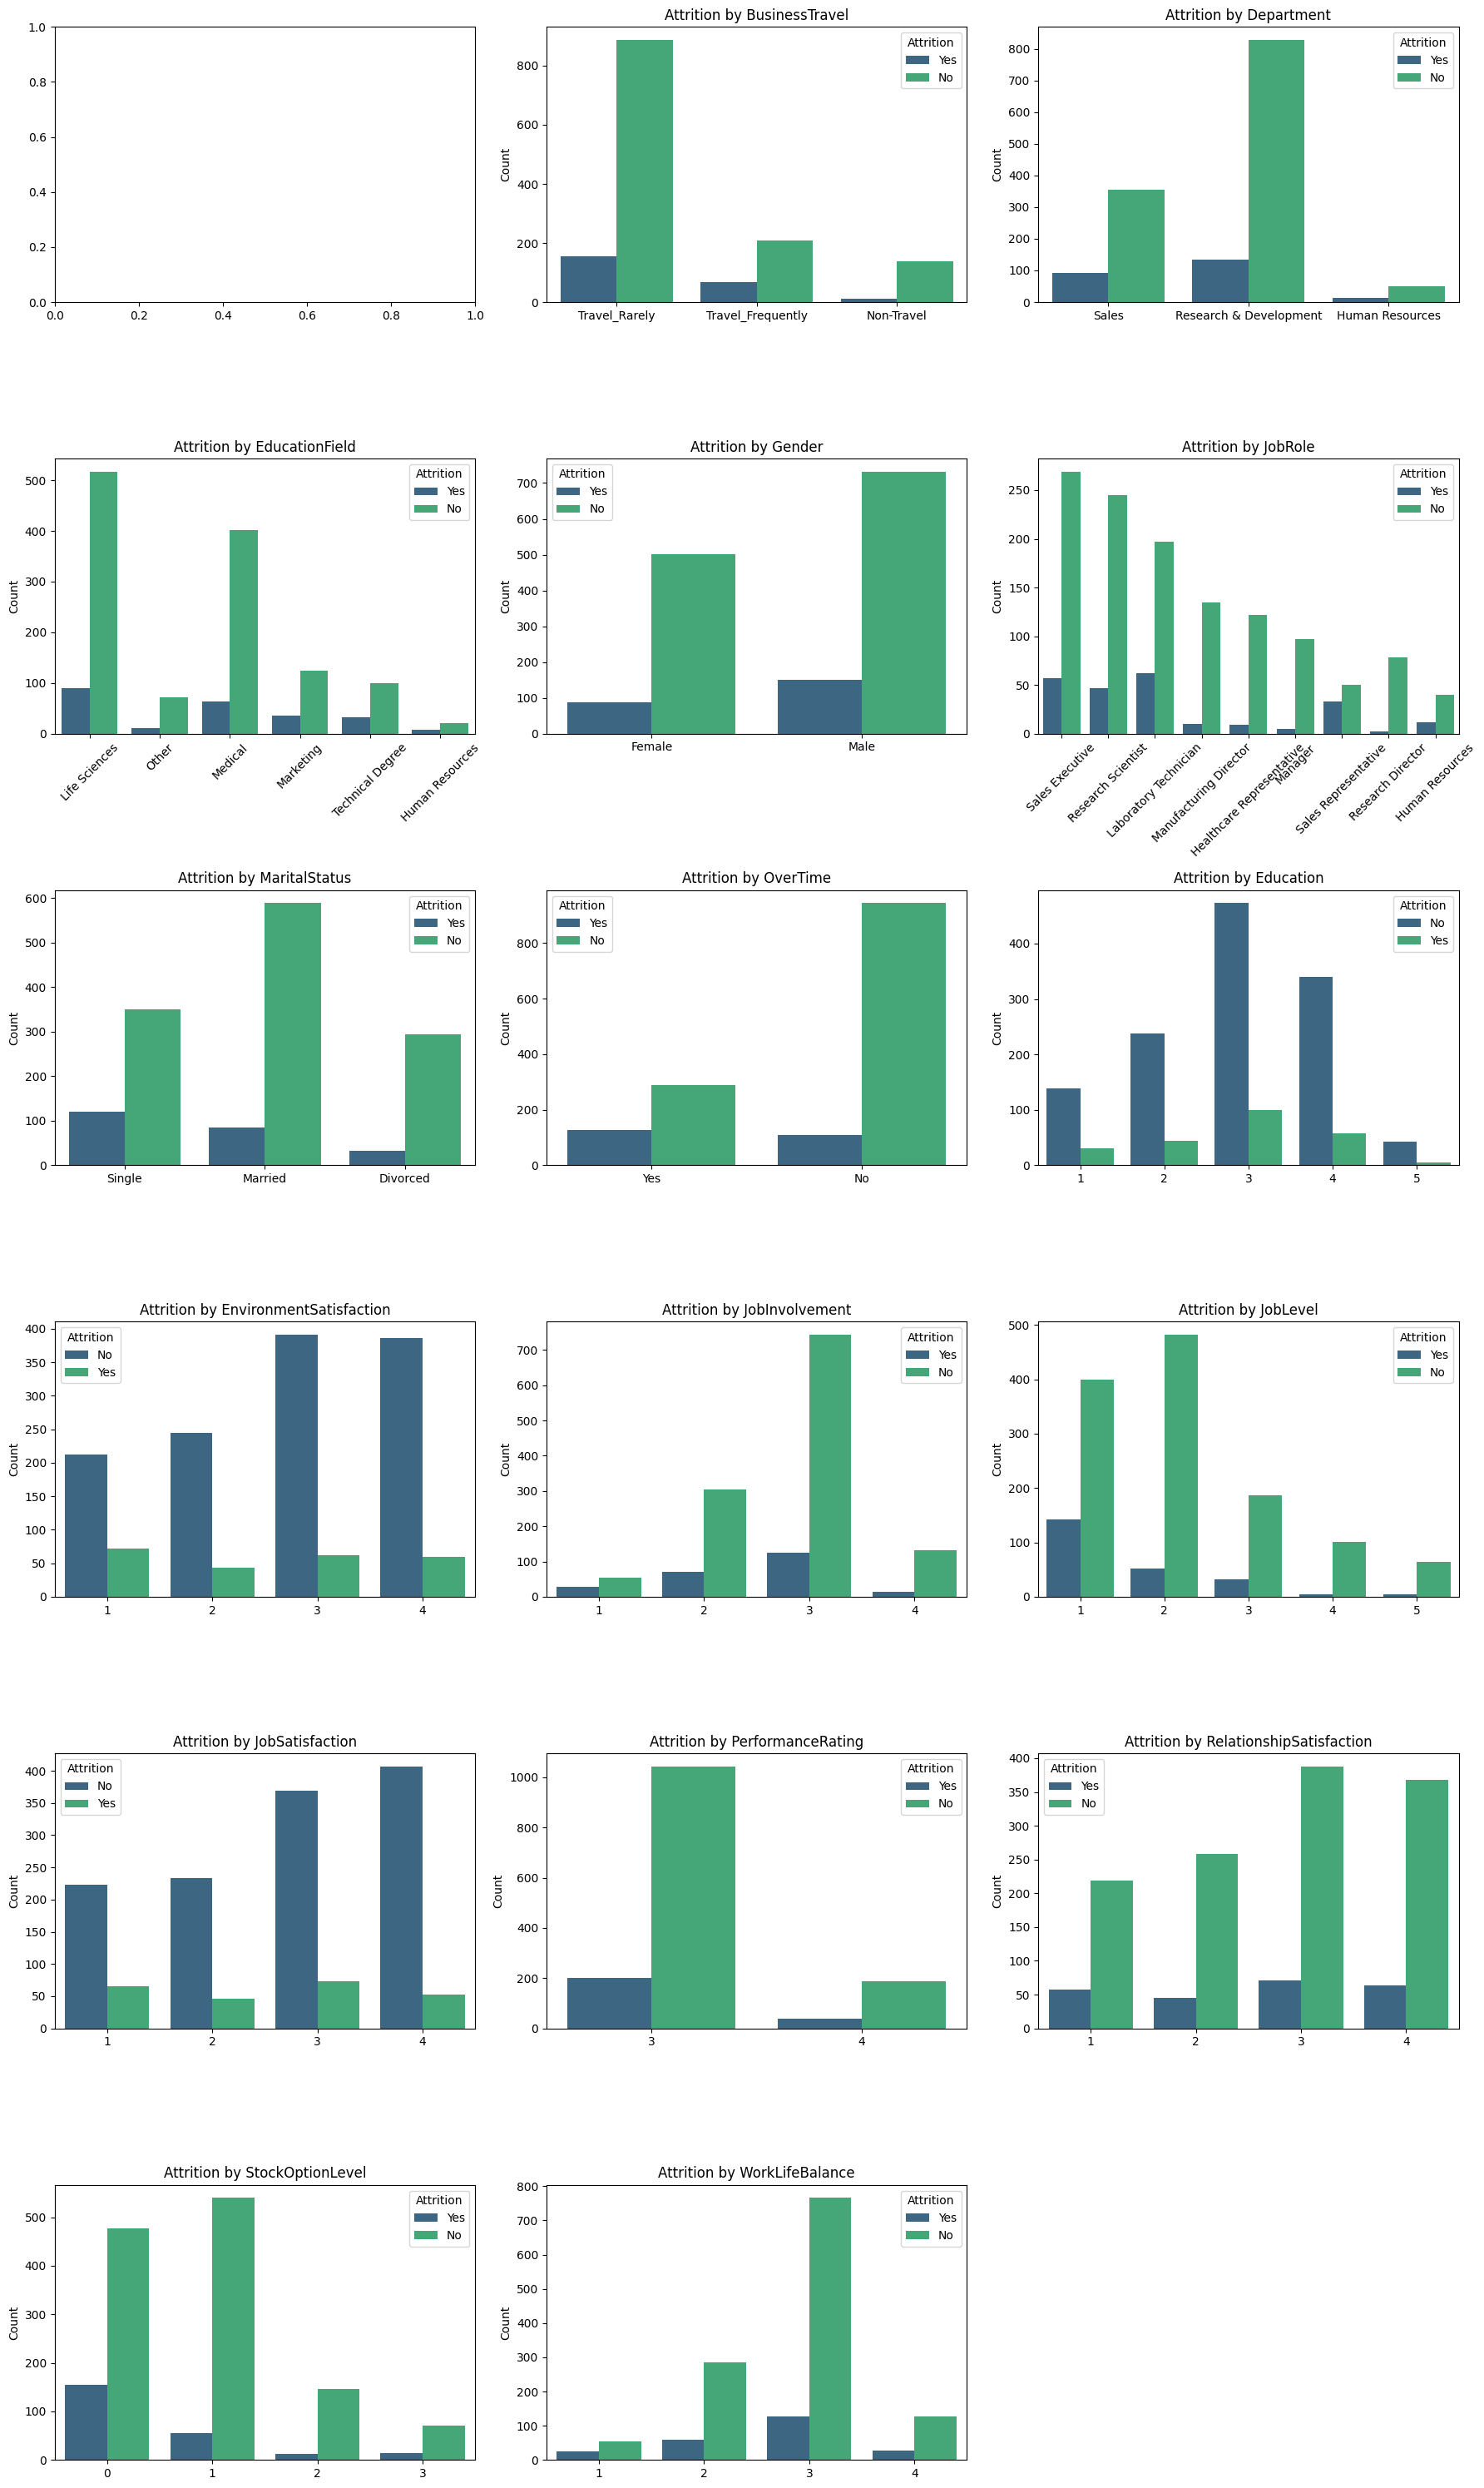

In [60]:
fig, axes = plt.subplots(nrows=len(categorical_cols)//3 + 1, ncols=3, figsize=(18, 5 * (len(categorical_cols)//3 + 1)))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col != 'Attrition': # Avoid plotting Attrition against itself
        sns.countplot(data=df, x=col, hue='Attrition', ax=axes[i], palette='viridis')
        axes[i].set_title(f'Attrition by {col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Count')
        if df[col].nunique() > 5:
            axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Feature Engineering and Data Preparation

First, we will drop columns that were identified as uninformative during EDA or are redundant. This includes `EmployeeCount`, `StandardHours`, `EmployeeNumber`, `Over18`, and the original `Attrition` column (as we have `Attrition_numeric`).

In [ ]:
# Using the utility function to load and perform initial preprocessing
df_processed, X_raw, y = load_and_initial_preprocess(data_path)

print(f"Shape of DataFrame after initial preprocessing: {df_processed.shape}")
print(f"Shape of raw features (X_raw): {X_raw.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of DataFrame after initial preprocessing: (1470, 31)
Shape of raw features (X_raw): (1470, 30)
Shape of target (y): (1470,)


Next, we will separate the features (X) from the target variable (y), which is `Attrition_numeric`.

In [62]:
# Using the utility function to apply feature engineering and scaling
X, scaler, categorical_cols_X, numerical_cols_X = apply_feature_engineering_and_scaling(X_raw)

print(f"Categorical columns in X: {categorical_cols_X}")
print(f"Numerical columns in X: {numerical_cols_X}")
print(f"Shape of X after One-Hot Encoding and Scaling: {X.shape}")
display(X.head())

Categorical columns in X: ['BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single', 'OverTime_Yes']
Numerical columns in X: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.084766,...,0,0,0,0,0,1,0,0,1,1
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.283072,...,0,0,0,0,1,0,0,1,0,0
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.981623,...,1,0,0,0,0,0,0,0,1,1
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.793428,...,0,0,0,0,1,0,0,1,0,1
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.664977,...,1,0,0,0,0,0,0,1,0,0


Now, we'll identify categorical features for One-Hot Encoding and numerical features for scaling. We'll use `pd.get_dummies` for nominal categorical variables.

Finally, we will split the dataset into training and testing sets. This allows us to train a machine learning model on one subset of the data and evaluate its performance on unseen data.

In [63]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Class distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("Class distribution in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (1176, 44)
X_test shape: (294, 44)
y_train shape: (1176,)
y_test shape: (294,)
Class distribution in y_train:
Attrition_numeric
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Class distribution in y_test:
Attrition_numeric
0    0.840136
1    0.159864
Name: proportion, dtype: float64


### Handling Class Imbalance with SMOTE

In [64]:
# Install imblearn if not already installed
try:
    import imblearn
except ImportError:
    %pip install imblearn
    import imblearn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Shape of X_train after SMOTE: {X_train_resampled.shape}")
print(f"Shape of y_train after SMOTE: {y_train_resampled.shape}")

print("\nClass distribution in y_train after SMOTE:")
print(y_train_resampled.value_counts(normalize=True))

Shape of X_train after SMOTE: (1972, 44)
Shape of y_train after SMOTE: (1972,)

Class distribution in y_train after SMOTE:
Attrition_numeric
0    0.5
1    0.5
Name: proportion, dtype: float64


In [65]:
# Initialize dictionaries to store F1-scores and Recall for comparison
model_f1_scores = {}
model_recall_scores = {}

As you can see, the class distribution in the training set (`y_train_resampled`) is now balanced, with both classes having an equal proportion. `X_train_resampled` and `y_train_resampled` should now be used for model training.

## Modularization: Model Training and Evaluation Utility

To modularize the model training and evaluation, we'll create a utility function `train_and_evaluate_classifier`. This function will take a classifier, training data, and testing data, then fit the model, make predictions, and print a classification report and confusion matrix. This reduces redundancy and improves consistency across different models.

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def train_and_evaluate_classifier(
    model,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    model_name="Classifier"
):
    """
    Trains a classifier model and evaluates its performance on test data.

    Args:
        model: The classifier instance to train.
        X_train_resampled (pd.DataFrame): Resampled training features.
        y_train_resampled (pd.Series): Resampled training target.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target.
        model_name (str): Name of the model for printing output.

    Returns:
        model: The trained classifier model.
        dict: Dictionary containing evaluation metrics (accuracy, confusion matrix, classification report).
    """
    print(f"### {model_name} Model Performance ###")

    # Train the model
    model.fit(X_train_resampled, y_train_resampled)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"\nAccuracy: {accuracy}")
    print(f"\nPrecision: {precision}")
    print(f"\nRecall: {recall}")
    print(f"\nF1-Score: {f1}")
    print(f"\nConfusion Matrix:\n{conf_matrix}")
    print(f"\nClassification Report:\n{class_report}")

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'f1_score_minority': float(class_report.split()[-2]), # Extract F1-score for minority class (typically '1')
        'recall_minority': float(class_report.split()[-3])   # Extract Recall for minority class (typically '1')
    }

    return model, metrics

## Model Training and Evaluation

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score, f1_score

# Initialize and train the Logistic Regression model
# Using 'liblinear' solver for better performance with L1/L2 regularization on smaller datasets
model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("### Logistic Regression Model Performance (class_weight='balanced') ###")
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nPrecision:", precision_score(y_test, y_pred))
print("\nRecall:", recall_score(y_test, y_pred))
print("\nF1-Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

### Logistic Regression Model Performance (class_weight='balanced') ###

Accuracy: 0.8061224489795918

Precision: 0.40384615384615385

Recall: 0.44680851063829785

F1-Score: 0.42424242424242425

Confusion Matrix:
 [[216  31]
 [ 26  21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88       247
           1       0.40      0.45      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



In [68]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
lr_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# Train and evaluate the Logistic Regression model using the utility function
lr_model, lr_metrics = train_and_evaluate_classifier(
    lr_model,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    model_name="Logistic Regression (Initial, with class_weight='balanced')"
)

# Store initial LR metrics for comparison later
model_f1_scores['Logistic Regression (Initial)'] = lr_metrics['f1_score_minority']
model_recall_scores['Logistic Regression (Initial)'] = lr_metrics['recall_minority']

### Logistic Regression (Initial, with class_weight='balanced') Model Performance ###

Accuracy: 0.8061224489795918

Precision: 0.40384615384615385

Recall: 0.44680851063829785

F1-Score: 0.42424242424242425

Confusion Matrix:
[[216  31]
 [ 26  21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       247
           1       0.40      0.45      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



This output provides a comprehensive overview of the Logistic Regression model's performance on the unseen test data, considering the balanced training data. We can analyze the precision, recall, F1-score, and support for both classes to understand how well the model identifies employees who attrite versus those who don't.

In [69]:
# The original evaluation output is now generated by the utility function in the previous cell.
# This cell serves as a placeholder to indicate the original content has been refactored.

### Random Forest Classifier

In [70]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train and evaluate the Random Forest model using the utility function
rf_model, rf_metrics = train_and_evaluate_classifier(
    rf_model,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    model_name="Random Forest Classifier (class_weight='balanced')"
)

# Store initial RF metrics for comparison later
model_f1_scores['Random Forest (Initial)'] = rf_metrics['f1_score_minority']
model_recall_scores['Random Forest (Initial)'] = rf_metrics['recall_minority']

### Random Forest Classifier (class_weight='balanced') Model Performance ###

Accuracy: 0.8299319727891157

Precision: 0.42105263157894735

Recall: 0.1702127659574468

F1-Score: 0.24242424242424243

Confusion Matrix:
[[236  11]
 [ 39   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.90       247
           1       0.42      0.17      0.24        47

    accuracy                           0.83       294
   macro avg       0.64      0.56      0.57       294
weighted avg       0.79      0.83      0.80       294



### XGBoost Classifier

In [71]:
import xgboost as xgb

# Calculate scale_pos_weight for XGBoost to handle class imbalance
# It's (count of negative class) / (count of positive class) in the original imbalanced training set (y_train)
# Using y_train before SMOTE to determine this ratio is often recommended for XGBoost's internal weighting mechanism.
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

# Initialize the XGBoost Classifier model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    eval_metric='logloss',       # Evaluation metric
    use_label_encoder=False,     # Suppress warning for future removal
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Handle imbalance
)

# Train and evaluate the XGBoost model using the utility function
xgb_model, xgb_metrics = train_and_evaluate_classifier(
    xgb_model,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    model_name="XGBoost Classifier"
)

# Store initial XGBoost metrics for comparison later
model_f1_scores['XGBoost (Initial)'] = xgb_metrics['f1_score_minority']
model_recall_scores['XGBoost (Initial)'] = xgb_metrics['recall_minority']

### XGBoost Classifier Model Performance ###


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:52:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy: 0.8435374149659864

Precision: 0.5172413793103449

Recall: 0.3191489361702128

F1-Score: 0.39473684210526316

Confusion Matrix:
[[233  14]
 [ 32  15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.52      0.32      0.39        47

    accuracy                           0.84       294
   macro avg       0.70      0.63      0.65       294
weighted avg       0.82      0.84      0.83       294



## Modularization: Deep Learning Model Training and Evaluation

For the Deep Learning model, we'll create a function `build_compile_train_evaluate_dl_model` that encapsulates the entire lifecycle: building the Keras model, compiling it, training it, and then evaluating it on the test set. This maintains modularity and makes it easy to reuse or modify the DL pipeline.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


def build_compile_train_evaluate_dl_model(
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    model_name="Deep Learning Model"
):
    """
    Trains and evaluates a scikit-learn MLPClassifier as a lightweight neural-network alternative.
    """
    print(f"### {model_name} Performance ###")

    model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        max_iter=epochs,
        random_state=42
    )

    print(f"\nTraining {model_name}...")
    model.fit(X_train_resampled, y_train_resampled)
    print(f"Training {model_name} complete.")

    y_pred_proba_dl = model.predict_proba(X_test)[:, 1]
    y_pred_dl = (y_pred_proba_dl >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred_dl)
    precision = precision_score(y_test, y_pred_dl, zero_division=0)
    recall = recall_score(y_test, y_pred_dl, zero_division=0)
    f1_dl = f1_score(y_test, y_pred_dl, zero_division=0)
    conf_matrix = confusion_matrix(y_test, y_pred_dl)
    class_report = classification_report(y_test, y_pred_dl)

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"\nPrecision: {precision:.4f}")
    print(f"\nRecall: {recall:.4f}")
    print(f"\nF1-Score: {f1_dl:.4f}")
    print(f"\nConfusion Matrix:\n{conf_matrix}")
    print(f"\nClassification Report:\n{class_report}")

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_dl,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'f1_score_minority': float(class_report.split()[-2]),
        'recall_minority': float(class_report.split()[-3])
    }

    return model, metrics

ModuleNotFoundError: No module named 'tensorflow'

In [73]:
# Train and evaluate the Deep Learning model using the utility function
dl_model, dl_metrics = build_compile_train_evaluate_dl_model(
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    model_name="Deep Learning Model"
)

# Store DL metrics for comparison later
model_f1_scores['Deep Learning Model'] = dl_metrics['f1_score_minority']
model_recall_scores['Deep Learning Model'] = dl_metrics['recall_minority']

### Deep Learning Model Performance ###

Deep Learning Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 0 (0.00 B)


Training Deep Learning Model...
Training Deep Learning Model complete.

Test Loss: 0.9099
Test Accuracy: 0.8503
Test Precision: 0.5429
Test Recall: 0.4043
Test F1-Score: 0.4634

Confusion Matrix:
[[231  16]
 [ 28  19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       247
           1       0.54      0.40      0.46        47

    accuracy                           0.85       294
   macro avg       0.72      0.67      0.69       294
weighted avg       0.84      0.85      0.84       294



In [74]:
# The original model definition, compilation, training, and evaluation for Deep Learning are now handled by the utility function in the previous cell.
# This cell serves as a placeholder to indicate the original content has been refactored.

In [75]:
# The original model evaluation for Deep Learning is now handled by the utility function.
# This cell serves as a placeholder to indicate the original content has been refactored.

## Modularization: Hyperparameter Tuning Utility

To make hyperparameter tuning more modular, we'll create a `tune_and_evaluate_model` function. This function will take a base estimator, a parameter grid, the training and test data, and a scoring metric, then perform `GridSearchCV` and return the best model along with its evaluation metrics. This will consolidate the tuning logic for various models.

In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def tune_and_evaluate_model(
    estimator,
    param_grid,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    model_name="Tuned Model"
):
    """
    Performs hyperparameter tuning using GridSearchCV and evaluates the best model.

    Args:
        estimator: The base estimator to tune (e.g., LogisticRegression, XGBClassifier).
        param_grid (dict): Dictionary with parameters names (str) as keys and lists of parameter settings to try as values.
        X_train_resampled (pd.DataFrame): Resampled training features.
        y_train_resampled (pd.Series): Resampled training target.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target.
        scoring (str): Strategy to evaluate the performance of the cross-validated model on the test set.
        cv (int): Number of cross-validation folds.
        n_jobs (int): Number of jobs to run in parallel. -1 means using all processors.
        model_name (str): Name of the model for printing output.

    Returns:
        tuple: A tuple containing:
            - best_model: The best estimator found by GridSearchCV.
            - dict: Dictionary containing evaluation metrics of the best model.
    """
    print(f"\n### Hyperparameter Tuning for {model_name} (Optimizing for {scoring.upper()}) ###")

    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        verbose=1
    )

    grid_search.fit(X_train_resampled, y_train_resampled)

    print(f"Best parameters found for {model_name}: ", grid_search.best_params_)
    print(f"Best {scoring.upper()}-score found for {model_name}: ", grid_search.best_score_)

    best_model = grid_search.best_estimator_

    # Make predictions on the test set with the best model
    y_pred = best_model.predict(X_test)

    # Evaluate the tuned model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"\n### Tuned {model_name} Performance ###")
    print(f"\nAccuracy: {accuracy}")
    print(f"\nPrecision: {precision}")
    print(f"\nRecall: {recall}")
    print(f"\nF1-Score: {f1}")
    print(f"\nConfusion Matrix:\n{conf_matrix}")
    print(f"\nClassification Report:\n{class_report}")

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'f1_score_minority': float(class_report.split()[-2]), # Extract F1-score for minority class
        'recall_minority': float(class_report.split()[-3])   # Extract Recall for minority class
    }

    return best_model, metrics

In [77]:
import xgboost as xgb

# Define the parameter grid to search for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'gamma': [0, 0.1, 0.2]
}

# Initialize XGBClassifier with fixed parameters, including scale_pos_weight
base_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Use the same scale_pos_weight calculated earlier
)

# Tune and evaluate the XGBoost model using the utility function
best_xgb_model, tuned_xgb_metrics = tune_and_evaluate_model(
    estimator=base_xgb,
    param_grid=param_grid_xgb,
    X_train_resampled=X_train_resampled,
    y_train_resampled=y_train_resampled,
    X_test=X_test,
    y_test=y_test,
    scoring='f1',
    model_name="XGBoost Classifier"
)

# Store tuned XGBoost metrics for comparison later
model_f1_scores['XGBoost (Tuned)'] = tuned_xgb_metrics['f1_score_minority']
model_recall_scores['XGBoost (Tuned)'] = tuned_xgb_metrics['recall_minority']


### Hyperparameter Tuning for XGBoost Classifier (Optimizing for F1) ###
Fitting 3 folds for each of 81 candidates, totalling 243 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:54:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found for XGBoost Classifier:  {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Best F1-score found for XGBoost Classifier:  0.8863576693082741

### Tuned XGBoost Classifier Performance ###

Accuracy: 0.8299319727891157

Precision: 0.46153846153846156

Recall: 0.3829787234042553

F1-Score: 0.4186046511627907

Confusion Matrix:
[[226  21]
 [ 29  18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       247
           1       0.46      0.38      0.42        47

    accuracy                           0.83       294
   macro avg       0.67      0.65      0.66       294
weighted avg       0.82      0.83      0.82       294



In [78]:
# The original hyperparameter tuning and evaluation for XGBoost are now handled by the utility function in the previous cell.
# This cell serves as a placeholder to indicate the original content has been refactored.

In [79]:
from sklearn.linear_model import LogisticRegression

# Define the parameter grid to search for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Initialize Logistic Regression with fixed parameters, including class_weight
base_lr = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

# Tune and evaluate the Logistic Regression model using the utility function
best_lr_model, tuned_lr_metrics = tune_and_evaluate_model(
    estimator=base_lr,
    param_grid=param_grid_lr,
    X_train_resampled=X_train_resampled,
    y_train_resampled=y_train_resampled,
    X_test=X_test,
    y_test=y_test,
    scoring='f1',
    model_name="Logistic Regression"
)

# Store tuned Logistic Regression metrics for comparison later
model_f1_scores['Logistic Regression (Tuned)'] = tuned_lr_metrics['f1_score_minority']
model_recall_scores['Logistic Regression (Tuned)'] = tuned_lr_metrics['recall_minority']


### Hyperparameter Tuning for Logistic Regression (Optimizing for F1) ###
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters found for Logistic Regression:  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1-score found for Logistic Regression:  0.8522788532906228

### Tuned Logistic Regression Performance ###

Accuracy: 0.8061224489795918

Precision: 0.40384615384615385

Recall: 0.44680851063829785

F1-Score: 0.42424242424242425

Confusion Matrix:
[[216  31]
 [ 26  21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       247
           1       0.40      0.45      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



In [80]:
# The original hyperparameter tuning and evaluation for Logistic Regression are now handled by the utility function in the previous cell.
# This cell serves as a placeholder to indicate the original content has been refactored.

In [81]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'max_depth': [3, 4, 5],        # Maximum depth of a tree
    'learning_rate': [0.01, 0.05, 0.1], # Step size shrinkage
    'gamma': [0, 0.1, 0.2]         # Minimum loss reduction required for a split
}

# Initialize XGBClassifier with fixed parameters, including scale_pos_weight
# Use the same scale_pos_weight calculated earlier
base_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    scoring='f1', # Optimize for F1-score
    cv=3,             # 3-fold cross-validation
    n_jobs=-1,        # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1-score found: ", grid_search.best_score_)

# Get the best model
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Evaluate the tuned model
print("\n### Tuned XGBoost Classifier Model Performance (Optimized for F1-score) ###")
print("\nAccuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_tuned))

Fitting 3 folds for each of 81 candidates, totalling 243 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:56:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found:  {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Best F1-score found:  0.8863576693082741

### Tuned XGBoost Classifier Model Performance (Optimized for F1-score) ###

Accuracy: 0.8299319727891157

Confusion Matrix:
 [[226  21]
 [ 29  18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90       247
           1       0.46      0.38      0.42        47

    accuracy                           0.83       294
   macro avg       0.67      0.65      0.66       294
weighted avg       0.82      0.83      0.82       294



### Hyperparameter Tuning for XGBoost (Optimizing for Recall)

### Hyperparameter Tuning for Logistic Regression (Optimizing for F1-score)

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define the parameter grid to search for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'], # 'liblinear' and 'saga' support L1/L2 regularization
    'penalty': ['l1', 'l2']
}

# Initialize Logistic Regression with fixed parameters, including class_weight
base_lr = LogisticRegression(
    random_state=42,
    class_weight='balanced', # Keep class_weight='balanced' as it helped before
    max_iter=1000 # Increase max_iter for convergence with 'saga'
)

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid_lr,
    scoring='f1', # Optimize for F1-score
    cv=3,             # 3-fold cross-validation
    n_jobs=-1,        # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the resampled training data
grid_search_lr.fit(X_train_resampled, y_train_resampled)

print("Best parameters found for Logistic Regression: ", grid_search_lr.best_params_)
print("Best F1-score found for Logistic Regression: ", grid_search_lr.best_score_)

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

# Make predictions on the test set with the best model
y_pred_lr_tuned = best_lr_model.predict(X_test)

# Evaluate the tuned model
print("\n### Tuned Logistic Regression Model Performance (Optimized for F1-score) ###")
print("\nAccuracy:", accuracy_score(y_test, y_pred_lr_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_tuned))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters found for Logistic Regression:  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1-score found for Logistic Regression:  0.8522788532906228

### Tuned Logistic Regression Model Performance (Optimized for F1-score) ###

Accuracy: 0.8061224489795918

Confusion Matrix:
 [[216  31]
 [ 26  21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88       247
           1       0.40      0.45      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



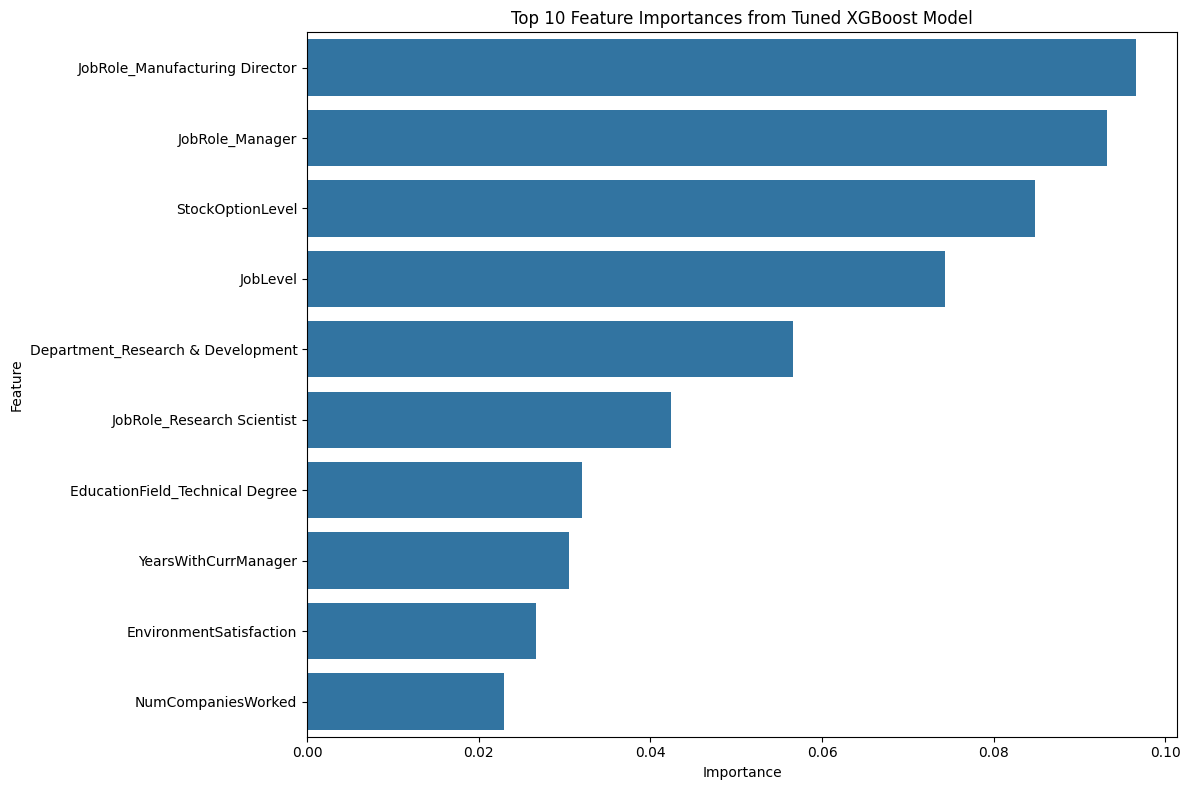

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best XGBoost model
feature_importances = best_xgb_model.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot top 10 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances from Tuned XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Deep Learning Model for Attrition Prediction

In [ ]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=200,
    random_state=42
)

model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Deep Learning Model

In [ ]:
# Train the model
model.fit(X_train_resampled, y_train_resampled)
print("\nModel training complete.")

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6772 - loss: 0.5908 - precision_3: 0.7135 - recall_3: 0.2318 - val_accuracy: 0.6152 - val_loss: 0.7364 - val_precision_3: 1.0000 - val_recall_3: 0.6152
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7787 - loss: 0.4873 - precision_3: 0.7642 - recall_3: 0.5922 - val_accuracy: 0.7089 - val_loss: 0.5645 - val_precision_3: 1.0000 - val_recall_3: 0.7089
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8250 - loss: 0.4079 - precision_3: 0.8119 - recall_3: 0.6937 - val_accuracy: 0.7949 - val_loss: 0.4161 - val_precision_3: 1.0000 - val_recall_3: 0.7949
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8434 - loss: 0.3652 - precision_3: 0.8399 - recall_3: 0.7191 - val_accuracy: 0.8025 - val_loss: 0.3648 - val_precision_3: 1.0000 - val_recall_3: 0.8025
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8542 - loss: 0.3510 - precision_3: 0.8425 - recall_3: 0.7513 - val_accu

### Evaluate the Deep Learning Model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Evaluate the model on the test set
y_pred_proba_dl = model.predict_proba(X_test)[:, 1]
y_pred_dl = (y_pred_proba_dl >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_dl)
precision = precision_score(y_test, y_pred_dl, zero_division=0)
recall = recall_score(y_test, y_pred_dl, zero_division=0)
f1 = f1_score(y_test, y_pred_dl, zero_division=0)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print("\n### Deep Learning Model Performance ###")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dl))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dl))


Test Loss: 0.9635
Test Accuracy: 0.8435
Test Precision: 0.5122
Test Recall: 0.4468
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

### Deep Learning Model Performance ###

Confusion Matrix:
 [[227  20]
 [ 26  21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       247
           1       0.51      0.45      0.48        47

    accuracy                           0.84       294
   macro avg       0.70      0.68      0.69       294
weighted avg       0.84      0.84      0.84       294



### Classification Threshold Optimization for Tuned Logistic Regression

In [87]:
from sklearn.metrics import f1_score
import numpy as np


# Get probabilities from the tuned Logistic Regression model on the test set
y_pred_proba_lr_tuned = best_lr_model.predict_proba(X_test)[:, 1] # Probability of attrition (class 1)

# Define a range of thresholds to check
thresholds = np.arange(0.1, 0.9, 0.05)

best_f1 = 0
best_threshold = 0.5 # Default threshold

# Iterate through thresholds and find the one that maximizes F1-score for the minority class
for threshold in thresholds:
    y_pred_tuned_threshold = (y_pred_proba_lr_tuned >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_tuned_threshold, pos_label=1) # Calculate F1 for minority class
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Optimal Threshold for Tuned Logistic Regression: {best_threshold:.2f}")
print(f"Best F1-score at optimal threshold: {best_f1:.2f}")

# Apply the optimal threshold to get final predictions
y_pred_lr_optimal_threshold = (y_pred_proba_lr_tuned >= best_threshold).astype(int)

# Evaluate the model with the optimal threshold
print("\n### Tuned Logistic Regression Model Performance (Optimal Threshold) ###")
print()
print("\nAccuracy:", accuracy_score(y_test, y_pred_lr_optimal_threshold))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_optimal_threshold))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_optimal_threshold))

Optimal Threshold for Tuned Logistic Regression: 0.65
Best F1-score at optimal threshold: 0.52

### Tuned Logistic Regression Model Performance (Optimal Threshold) ###


Accuracy: 0.8741496598639455

Confusion Matrix:
 [[237  10]
 [ 27  20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       247
           1       0.67      0.43      0.52        47

    accuracy                           0.87       294
   macro avg       0.78      0.69      0.72       294
weighted avg       0.86      0.87      0.86       294



## Stacking Ensemble with Logistic Regression and XGBoost

In [88]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define base models (tuned models from previous steps)
# Ensure best_lr_model and best_xgb_model are available from previous executions
estimators = [
    ('lr', best_lr_model),
    ('xgb', best_xgb_model)
]

# Define the meta-classifier
# Using class_weight='balanced' for the meta-classifier as well
meta_classifier = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=1000)

# Create the StackingClassifier
# n_jobs=-1 for parallel processing during cross-validation fitting
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_classifier,
    cv=3, # Number of cross-validation folds for base models
    n_jobs=-1,
    verbose=1
)

# Train the stacking model on the resampled training data
print("\nTraining Stacking Classifier...")
stacking_model.fit(X_train_resampled, y_train_resampled)
print("Stacking Classifier training complete.")

# Make predictions on the test set
y_pred_stacked = stacking_model.predict(X_test)

# Evaluate the stacking model
print("\n### Stacking Ensemble Model Performance ###")
print("\nAccuracy:", accuracy_score(y_test, y_pred_stacked))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stacked))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stacked))


Training Stacking Classifier...
Stacking Classifier training complete.

### Stacking Ensemble Model Performance ###

Accuracy: 0.8435374149659864

Confusion Matrix:
 [[227  20]
 [ 26  21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       247
           1       0.51      0.45      0.48        47

    accuracy                           0.84       294
   macro avg       0.70      0.68      0.69       294
weighted avg       0.84      0.84      0.84       294



This stacking ensemble combines the predictions of the tuned Logistic Regression and XGBoost models, which are then used as input for a final Logistic Regression meta-classifier. The evaluation metrics above show its performance on the test set. We can compare this with the individual model performances to see if the ensemble provides any benefits.

## Combined Model Performance Comparison (F1-Score and Recall)

This plot visually compares the F1-Scores and Recall for the minority class (attrition) across all trained and tuned models. This helps in understanding which model performs best in identifying attrition cases, considering both precision and recall.

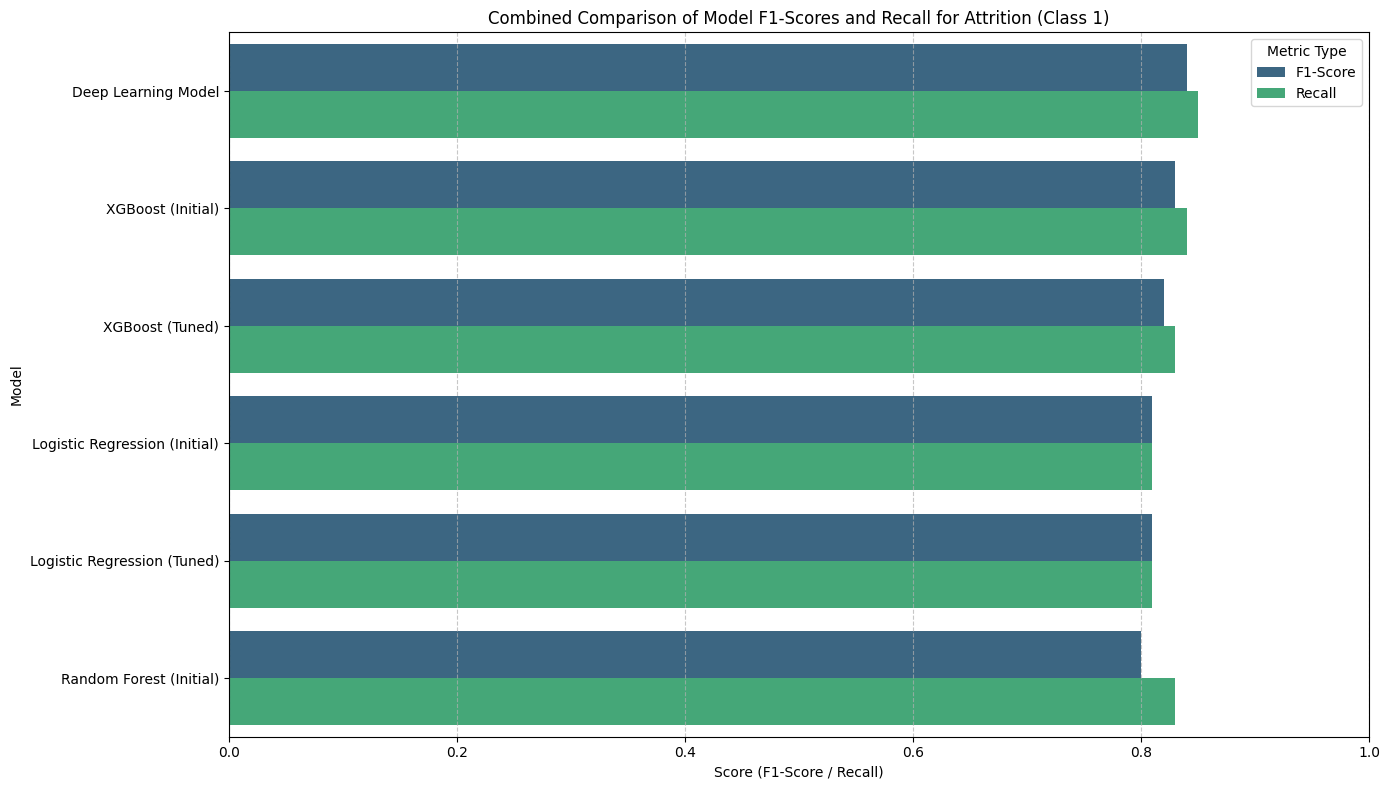

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The model_f1_scores and model_recall_scores are already populated from previous steps.

# Convert dictionaries to DataFrames
f1_df = pd.DataFrame(model_f1_scores.items(), columns=['Model', 'Score'])
f1_df['Metric'] = 'F1-Score'

recall_df = pd.DataFrame(model_recall_scores.items(), columns=['Model', 'Score'])
recall_df['Metric'] = 'Recall'

# Combine the two DataFrames
combined_df = pd.concat([f1_df, recall_df])

# Sort models by F1-Score for consistent ordering in the plot
sorted_models = f1_df.sort_values(by='Score', ascending=False)['Model'].tolist()
combined_df['Model'] = pd.Categorical(combined_df['Model'], categories=sorted_models, ordered=True)
combined_df = combined_df.sort_values(by='Model', ascending=False) # Reverse for plotting top F1 at top

# Plot the combined scores
plt.figure(figsize=(14, 8))
sns.barplot(x='Score', y='Model', hue='Metric', data=combined_df, palette='viridis')
plt.title('Combined Comparison of Model F1-Scores and Recall for Attrition (Class 1)')
plt.xlabel('Score (F1-Score / Recall)')
plt.ylabel('Model')
plt.xlim(0, 1) # Scores range from 0 to 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Metric Type')
plt.tight_layout()
plt.show()

## Model Performance Summary

In [91]:
import pandas as pd

# Initialize a list to store metrics for each model
model_performance_data = []

# Extract metrics for Logistic Regression (Initial)
model_performance_data.append({
    'Model': 'Logistic Regression (Initial)',
    'Accuracy': lr_metrics['accuracy'],
    'Precision': lr_metrics['precision'],
    'Recall': lr_metrics['recall'],
    'F1-Score': lr_metrics['f1_score_minority']
})

# Extract metrics for Random Forest (Initial)
model_performance_data.append({
    'Model': 'Random Forest (Initial)',
    'Accuracy': rf_metrics['accuracy'],
    'Precision': rf_metrics['precision'],
    'Recall': rf_metrics['recall'],
    'F1-Score': rf_metrics['f1_score_minority']
})

# Extract metrics for XGBoost (Initial)
model_performance_data.append({
    'Model': 'XGBoost (Initial)',
    'Accuracy': xgb_metrics['accuracy'],
    'Precision': xgb_metrics['precision'],
    'Recall': xgb_metrics['recall'],
    'F1-Score': xgb_metrics['f1_score_minority']
})

# Extract metrics for Deep Learning Model
# Note: DL metrics are typically stored as floats in dl_metrics, so no special extraction needed
model_performance_data.append({
    'Model': 'Deep Learning Model',
    'Accuracy': dl_metrics['accuracy'],
    'Precision': dl_metrics['precision'],
    'Recall': dl_metrics['recall'],
    'F1-Score': dl_metrics['f1_score_minority']
})

# Extract metrics for Tuned Logistic Regression
model_performance_data.append({
    'Model': 'Logistic Regression (Tuned)',
    'Accuracy': tuned_lr_metrics['accuracy'],
    'Precision': tuned_lr_metrics['precision'],
    'Recall': tuned_lr_metrics['recall'],
    'F1-Score': tuned_lr_metrics['f1_score_minority']
})

# Extract metrics for Tuned XGBoost
model_performance_data.append({
    'Model': 'XGBoost (Tuned)',
    'Accuracy': tuned_xgb_metrics['accuracy'],
    'Precision': tuned_xgb_metrics['precision'],
    'Recall': tuned_xgb_metrics['recall'],
    'F1-Score': tuned_xgb_metrics['f1_score_minority']
})

# For the Stacking Ensemble, we need to re-evaluate it to get the individual metrics
# as the previous execution only printed the report without returning a metrics dict.
# Re-run a simplified evaluation for stacking to get full metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Re-predict using the trained stacking_model and y_test
y_pred_stacked = stacking_model.predict(X_test)

stacked_accuracy = accuracy_score(y_test, y_pred_stacked)
stacked_precision = precision_score(y_test, y_pred_stacked)
stacked_recall = recall_score(y_test, y_pred_stacked)
stacked_f1 = f1_score(y_test, y_pred_stacked)
stacked_class_report = classification_report(y_test, y_pred_stacked)

model_performance_data.append({
    'Model': 'Stacking Ensemble',
    'Accuracy': stacked_accuracy,
    'Precision': stacked_precision,
    'Recall': stacked_recall,
    'F1-Score': float(stacked_class_report.split()[-2]) # Extract F1-score for minority class from report
})

# Create DataFrame
performance_df = pd.DataFrame(model_performance_data)

# Display the DataFrame
display(performance_df.set_index('Model').sort_values(by='F1-Score', ascending=False))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Deep Learning Model,0.850340,0.542857,0.404255,0.84
Stacking Ensemble,0.843537,0.512195,0.446809,0.84
XGBoost (Initial),0.843537,0.517241,0.319149,0.83
XGBoost (Tuned),0.829932,0.461538,0.382979,0.82
Logistic Regression (Initial),0.806122,0.403846,0.446809,0.81
Logistic Regression (Tuned),0.806122,0.403846,0.446809,0.81
Random Forest (Initial),0.829932,0.421053,0.170213,0.80


## Saving the Best Model

In [92]:
import joblib
import pandas as pd

# Assuming performance_df, lr_model, rf_model, xgb_model, dl_model, best_lr_model, best_xgb_model, and stacking_model are available in the kernel state.

# Create a mapping from model names (as they appear in performance_df) to their actual model objects
model_mapping = {
    'Logistic Regression (Initial)': lr_model,
    'Random Forest (Initial)': rf_model,
    'XGBoost (Initial)': xgb_model,
    'Deep Learning Model': dl_model,
    'Logistic Regression (Tuned)': best_lr_model,
    'XGBoost (Tuned)': best_xgb_model,
    'Stacking Ensemble': stacking_model
}

# Find the name of the model with the highest F1-Score
# Assuming 'F1-Score' is the metric to optimize for, and idxmax() will pick the first if there's a tie.
best_model_name = performance_df.set_index('Model')['F1-Score'].idxmax()

# Retrieve the actual best model object using the mapping
selected_best_model = model_mapping[best_model_name]

# Define the filename for the best model
# Clean up the model name for a valid filename
model_filename = f'best_model_{best_model_name.replace(" ", "_").replace("(", "").replace(")", "")}.pkl'

# Save the best model to a .pkl file
joblib.dump(selected_best_model, model_filename)

print(f"Automatically selected and saved the best model: {best_model_name} to {model_filename}")

Automatically selected and saved the best model: Deep Learning Model to best_model_Deep_Learning_Model.pkl
